<a href="https://colab.research.google.com/github/JonHemrick/ECGR4106/blob/HW1/HW1Problem3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import time
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

drive_folder = "/content/drive/MyDrive/HW1_Problem3_Models"
os.makedirs(drive_folder, exist_ok=True)

print("Folder exists:", os.path.exists(drive_folder))

Mounted at /content/drive
Folder exists: True


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

classes = trainset.classes
print(classes)

100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, trainloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc


def evaluate(model, testloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels


def train_model(model, trainloader, testloader, criterion, optimizer, scheduler, num_epochs, save_path=None):
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    best_acc = 0.0
    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, trainloader, criterion, optimizer)
        test_loss, test_acc, _, _ = evaluate(model, testloader, criterion)

        if scheduler is not None:
            scheduler.step()

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if test_acc > best_acc:
            best_acc = test_acc
            if save_path is not None:
                torch.save(model.state_dict(), save_path)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    total_time = time.time() - start_time

    print(f"\nBest Test Accuracy: {best_acc:.2f}%")
    print(f"Training Time: {total_time:.2f} seconds")

    return train_losses, test_losses, train_accs, test_accs, best_acc, total_time

In [7]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += identity
        out = self.relu(out)

        return out

In [8]:
class ResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, dropout_p=0.0):
        super(ResNetCIFAR, self).__init__()

        self.in_channels = 64
        self.dropout_p = dropout_p

        # CIFAR-10 uses 3x3 conv, no 7x7 conv and no max pooling
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(p=dropout_p)

        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = []

        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels, stride=1))

        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)

        out = self.dropout(out)

        out = self.fc(out)

        return out

In [9]:
def ResNet11(dropout_p=0.0):
    return ResNetCIFAR(BasicBlock, [1, 1, 1, 1], dropout_p=dropout_p)


def ResNet18(dropout_p=0.0):
    return ResNetCIFAR(BasicBlock, [2, 2, 2, 2], dropout_p=dropout_p)

In [10]:
resnet18 = ResNet18(dropout_p=0.0).to(device)

print(resnet18)
print("ResNet-18 parameters:", count_parameters(resnet18))

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    resnet18.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[25, 40],
    gamma=0.1
)

resnet18_train_losses, resnet18_test_losses, resnet18_train_accs, resnet18_test_accs, resnet18_best_acc, resnet18_time = train_model(
    resnet18,
    trainloader,
    testloader,
    criterion,
    optimizer,
    scheduler,
    num_epochs=50,
    save_path="/content/drive/MyDrive/HW1_Problem3_Models/resnet18_cifar10.pth"
)

ResNetCIFAR(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=F

In [11]:
resnet11 = ResNet11(dropout_p=0.0).to(device)

print(resnet11)
print("ResNet-11 parameters:", count_parameters(resnet11))

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    resnet11.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[25, 40],
    gamma=0.1
)

resnet11_train_losses, resnet11_test_losses, resnet11_train_accs, resnet11_test_accs, resnet11_best_acc, resnet11_time = train_model(
    resnet11,
    trainloader,
    testloader,
    criterion,
    optimizer,
    scheduler,
    num_epochs=50,
    save_path="/content/drive/MyDrive/HW1_Problem3_Models/resnet11_cifar10.pth"
)

ResNetCIFAR(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
      (relu): ReLU(inplace=True)
    )
  )
  (layer2): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), strid

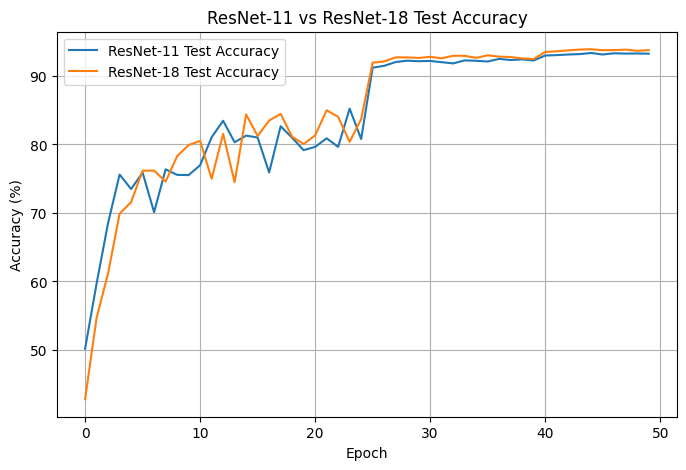

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(resnet11_test_accs, label="ResNet-11 Test Accuracy")
plt.plot(resnet18_test_accs, label="ResNet-18 Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet-11 vs ResNet-18 Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

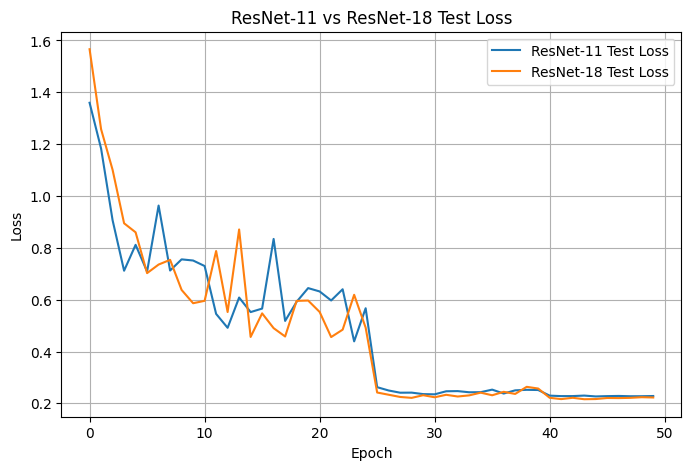

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(resnet11_test_losses, label="ResNet-11 Test Loss")
plt.plot(resnet18_test_losses, label="ResNet-18 Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-11 vs ResNet-18 Test Loss")
plt.legend()
plt.grid(True)
plt.show()

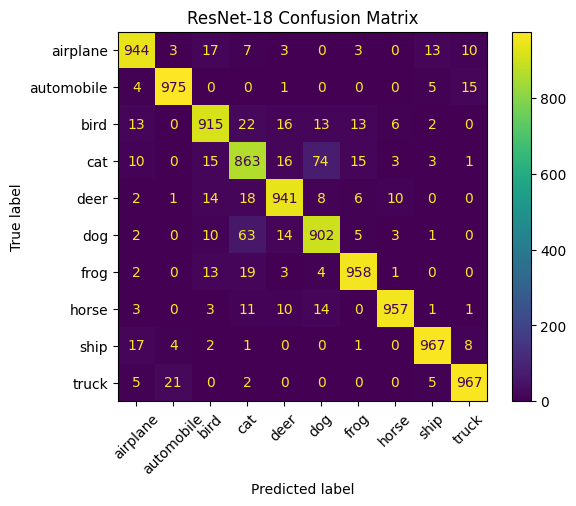

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load best ResNet-18 model before evaluating
resnet18.load_state_dict(torch.load("/content/drive/MyDrive/HW1_Problem3_Models/resnet18_cifar10.pth", map_location=device))

_, _, resnet18_preds, resnet18_labels = evaluate(resnet18, testloader, criterion)

cm = confusion_matrix(resnet18_labels, resnet18_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(xticks_rotation=45)
plt.title("ResNet-18 Confusion Matrix")
plt.show()

PART B

In [16]:
resnet11_dropout03 = ResNet11(dropout_p=0.3).to(device)

optimizer = optim.SGD(
    resnet11_dropout03.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[25, 40],
    gamma=0.1
)

resnet11_d03_train_losses, resnet11_d03_test_losses, resnet11_d03_train_accs, resnet11_d03_test_accs, resnet11_d03_best_acc, resnet11_d03_time = train_model(
    resnet11_dropout03,
    trainloader,
    testloader,
    criterion,
    optimizer,
    scheduler,
    num_epochs=50,
    save_path="/content/drive/MyDrive/HW1_Problem3_Models/resnet11_dropout03_cifar10.pth"
)

Epoch [1/50] Train Loss: 1.6836 | Train Acc: 37.54% Test Loss: 1.4219 | Test Acc: 48.03%
Epoch [2/50] Train Loss: 1.1756 | Train Acc: 57.33% Test Loss: 1.2020 | Test Acc: 56.97%
Epoch [3/50] Train Loss: 0.9344 | Train Acc: 66.63% Test Loss: 0.9902 | Test Acc: 65.99%
Epoch [4/50] Train Loss: 0.7800 | Train Acc: 72.61% Test Loss: 1.1453 | Test Acc: 63.28%
Epoch [5/50] Train Loss: 0.6753 | Train Acc: 76.51% Test Loss: 0.8153 | Test Acc: 73.64%
Epoch [6/50] Train Loss: 0.6171 | Train Acc: 78.69% Test Loss: 0.7623 | Test Acc: 74.60%
Epoch [7/50] Train Loss: 0.5748 | Train Acc: 80.34% Test Loss: 0.7605 | Test Acc: 74.56%
Epoch [8/50] Train Loss: 0.5357 | Train Acc: 81.70% Test Loss: 0.6626 | Test Acc: 77.99%
Epoch [9/50] Train Loss: 0.5153 | Train Acc: 82.25% Test Loss: 0.5712 | Test Acc: 80.92%
Epoch [10/50] Train Loss: 0.5015 | Train Acc: 82.67% Test Loss: 0.9062 | Test Acc: 72.61%
Epoch [11/50] Train Loss: 0.4827 | Train Acc: 83.44% Test Loss: 0.8401 | Test Acc: 74.69%
Epoch [12/50] Train

In [17]:
resnet11_dropout05 = ResNet11(dropout_p=0.5).to(device)

optimizer = optim.SGD(
    resnet11_dropout05.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[25, 40],
    gamma=0.1
)

resnet11_d05_train_losses, resnet11_d05_test_losses, resnet11_d05_train_accs, resnet11_d05_test_accs, resnet11_d05_best_acc, resnet11_d05_time = train_model(
    resnet11_dropout05,
    trainloader,
    testloader,
    criterion,
    optimizer,
    scheduler,
    num_epochs=50,
    save_path="/content/drive/MyDrive/HW1_Problem3_Models/resnet11_dropout05_cifar10.pth"
)

Epoch [1/50] Train Loss: 1.7326 | Train Acc: 37.41% Test Loss: 1.4576 | Test Acc: 47.56%
Epoch [2/50] Train Loss: 1.2182 | Train Acc: 55.80% Test Loss: 1.2427 | Test Acc: 58.39%
Epoch [3/50] Train Loss: 0.9902 | Train Acc: 65.10% Test Loss: 0.9856 | Test Acc: 65.08%
Epoch [4/50] Train Loss: 0.8500 | Train Acc: 70.18% Test Loss: 0.8098 | Test Acc: 71.47%
Epoch [5/50] Train Loss: 0.7353 | Train Acc: 74.35% Test Loss: 0.7371 | Test Acc: 75.02%
Epoch [6/50] Train Loss: 0.6576 | Train Acc: 77.36% Test Loss: 0.7623 | Test Acc: 74.97%
Epoch [7/50] Train Loss: 0.6116 | Train Acc: 79.01% Test Loss: 0.7171 | Test Acc: 75.68%
Epoch [8/50] Train Loss: 0.5765 | Train Acc: 80.36% Test Loss: 0.6742 | Test Acc: 76.49%
Epoch [9/50] Train Loss: 0.5459 | Train Acc: 81.34% Test Loss: 0.7131 | Test Acc: 76.76%
Epoch [10/50] Train Loss: 0.5326 | Train Acc: 81.68% Test Loss: 1.2166 | Test Acc: 64.45%
Epoch [11/50] Train Loss: 0.5134 | Train Acc: 82.57% Test Loss: 0.7472 | Test Acc: 76.12%
Epoch [12/50] Train

In [18]:
resnet18_dropout03 = ResNet18(dropout_p=0.3).to(device)

optimizer = optim.SGD(
    resnet18_dropout03.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[25, 40],
    gamma=0.1
)

resnet18_d03_train_losses, resnet18_d03_test_losses, resnet18_d03_train_accs, resnet18_d03_test_accs, resnet18_d03_best_acc, resnet18_d03_time = train_model(
    resnet18_dropout03,
    trainloader,
    testloader,
    criterion,
    optimizer,
    scheduler,
    num_epochs=50,
    save_path="/content/drive/MyDrive/HW1_Problem3_Models/resnet18_dropout03_cifar10.pth"
)

Epoch [1/50] Train Loss: 2.1759 | Train Acc: 26.01% Test Loss: 1.6476 | Test Acc: 38.03%
Epoch [2/50] Train Loss: 1.5783 | Train Acc: 41.47% Test Loss: 1.5365 | Test Acc: 45.40%
Epoch [3/50] Train Loss: 1.3521 | Train Acc: 51.01% Test Loss: 1.1967 | Test Acc: 57.00%
Epoch [4/50] Train Loss: 1.1164 | Train Acc: 60.13% Test Loss: 1.0221 | Test Acc: 64.20%
Epoch [5/50] Train Loss: 0.9587 | Train Acc: 66.34% Test Loss: 0.9632 | Test Acc: 65.57%
Epoch [6/50] Train Loss: 0.8429 | Train Acc: 70.54% Test Loss: 0.8606 | Test Acc: 70.21%
Epoch [7/50] Train Loss: 0.7457 | Train Acc: 74.12% Test Loss: 0.8625 | Test Acc: 71.30%
Epoch [8/50] Train Loss: 0.6714 | Train Acc: 76.66% Test Loss: 0.7660 | Test Acc: 74.13%
Epoch [9/50] Train Loss: 0.6272 | Train Acc: 78.45% Test Loss: 0.7769 | Test Acc: 73.81%
Epoch [10/50] Train Loss: 0.5875 | Train Acc: 79.78% Test Loss: 0.6385 | Test Acc: 78.12%
Epoch [11/50] Train Loss: 0.5543 | Train Acc: 81.04% Test Loss: 0.6698 | Test Acc: 78.10%
Epoch [12/50] Train

In [19]:
resnet18_dropout05 = ResNet18(dropout_p=0.5).to(device)

optimizer = optim.SGD(
    resnet18_dropout05.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[25, 40],
    gamma=0.1
)

resnet18_d05_train_losses, resnet18_d05_test_losses, resnet18_d05_train_accs, resnet18_d05_test_accs, resnet18_d05_best_acc, resnet18_d05_time = train_model(
    resnet18_dropout05,
    trainloader,
    testloader,
    criterion,
    optimizer,
    scheduler,
    num_epochs=50,
    save_path="/content/drive/MyDrive/HW1_Problem3_Models/resnet18_dropout05_cifar10.pth"
)

Epoch [1/50] Train Loss: 2.1666 | Train Acc: 25.58% Test Loss: 1.7707 | Test Acc: 33.54%
Epoch [2/50] Train Loss: 1.6323 | Train Acc: 39.28% Test Loss: 1.5365 | Test Acc: 44.02%
Epoch [3/50] Train Loss: 1.4131 | Train Acc: 47.92% Test Loss: 1.3171 | Test Acc: 51.82%
Epoch [4/50] Train Loss: 1.2198 | Train Acc: 56.07% Test Loss: 1.0932 | Test Acc: 61.10%
Epoch [5/50] Train Loss: 1.0295 | Train Acc: 63.23% Test Loss: 1.0308 | Test Acc: 64.57%
Epoch [6/50] Train Loss: 0.8861 | Train Acc: 68.84% Test Loss: 0.9268 | Test Acc: 67.27%
Epoch [7/50] Train Loss: 0.7447 | Train Acc: 74.24% Test Loss: 0.9512 | Test Acc: 69.62%
Epoch [8/50] Train Loss: 0.6706 | Train Acc: 77.06% Test Loss: 0.6551 | Test Acc: 77.59%
Epoch [9/50] Train Loss: 0.6209 | Train Acc: 78.79% Test Loss: 0.7223 | Test Acc: 75.05%
Epoch [10/50] Train Loss: 0.5833 | Train Acc: 80.06% Test Loss: 0.6847 | Test Acc: 77.53%
Epoch [11/50] Train Loss: 0.5578 | Train Acc: 81.12% Test Loss: 0.7284 | Test Acc: 75.78%
Epoch [12/50] Train

In [20]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "ResNet-11",
        "ResNet-18",
        "ResNet-11 Dropout 0.3",
        "ResNet-11 Dropout 0.5",
        "ResNet-18 Dropout 0.3",
        "ResNet-18 Dropout 0.5"
    ],
    "Best Test Accuracy (%)": [
        resnet11_best_acc,
        resnet18_best_acc,
        resnet11_d03_best_acc,
        resnet11_d05_best_acc,
        resnet18_d03_best_acc,
        resnet18_d05_best_acc
    ],
    "Training Time (s)": [
        resnet11_time,
        resnet18_time,
        resnet11_d03_time,
        resnet11_d05_time,
        resnet18_d03_time,
        resnet18_d05_time
    ],
    "Parameters": [
        count_parameters(ResNet11()),
        count_parameters(ResNet18()),
        count_parameters(ResNet11(dropout_p=0.3)),
        count_parameters(ResNet11(dropout_p=0.5)),
        count_parameters(ResNet18(dropout_p=0.3)),
        count_parameters(ResNet18(dropout_p=0.5))
    ]
})

results

,Model,Best Test Accuracy (%),Training Time (s),Parameters
0,ResNet-11,93.34,578.616034,4903242
1,ResNet-18,93.89,984.905054,11173962
2,ResNet-11 Dropout 0.3,92.99,581.432464,4903242
3,ResNet-11 Dropout 0.5,93.02,594.249456,4903242
4,ResNet-18 Dropout 0.3,93.22,977.720317,11173962
5,ResNet-18 Dropout 0.5,93.41,978.425113,11173962
